# Hyperparameter Search for GPT2 of all sizes

The fine-tuning configuration depends on the following relevant parameters:
- Number of prime sentence [fixed]: 1 (aligning with transient activaiton);
- Number of epochs [fixed]: 10 (presenting the prime + fillers 10 times);
- **Learning rate [under search]**: usually 5e-6, 1e-5, 5e-5 work the best;

There is one more complication, which is the regularization done with the filler sentences:
- Squared [fixed]: True (not squaring doesn't really make sense);
- **Lambda [under search]**: lambda=0.8 works for GPT2-small; larger lambda may be needed for GPT2-large;
- Filler sentence [under search]:
    - **Number of filler tokens**;
    - **Padding or not**;
    - [Test this locally] For medium and large, whether to divide the reg_loss difference by the number of filler sentences.

To have a better sense of the priming effect, each hyperparameter combination is tested under **10 prime-target pairs**. The icnrease from baseline is averaged over the 10 pairs. It is fine for different model sizes to have different parameter combinations. For the small model, it is fine to give the filler sentences a sa whole batch. For medium and large models, we do it line by line.

Number of tokens without padding:
- **Tiny**: 950 (10 sentences)
- Small: 2310 (30 sentences)
- **Mid**: 2540 (30 sentences)
- Big: 3330 (30 sentences)
- **Xl**: 5380 (50 sentences)

GPT2-large takes 39GB on full batch of the `big` tokens (no_padding)

### Hypersearch Structure
- Each job will contain the **LR x LAMB** nexted loops; will record 10 prime-target pairs and take the average;
- [model size] x [filler size] x [padding or not] = 3 x 3 x 2
- we assume that we will do line-by-line filler processing, since GPT2-large cannot handle full batches


In [2]:
root_dir = '/vast/palmer/home.grace/zz436/neural_priming/'
import sys
sys.path.append(root_dir)
from priming_utils import *

import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from dataclasses import dataclass
from typing import Optional
import gc
import seaborn as sns
from tqdm.auto import tqdm
from transformer_lens import HookedTransformer, utils

torch.set_grad_enabled(True)

# Testing Search

### Arguments taken from command line

In [14]:
SIZE = 'medium' # medium, large
FILLER_SIZE = 'xl' # small, xl
PADDING = False # True
batch_size = 10

model_name = f'gpt2-{SIZE}'
model = HookedTransformer.from_pretrained(model_name, device=device)

Loaded pretrained model gpt2-medium into HookedTransformer


### Create the filler set

In [15]:
filler_path = f'{root_dir}fine-tuning/fillers_{FILLER_SIZE}.txt'
with open(filler_path, 'r') as f:
    fillers = [line.strip() for line in f.readlines()]
print(f'The set of {len(fillers)} fillers.')

long_tensor = torch.tensor([]).to(device)
for filler in fillers:
    long_tensor = torch.cat((long_tensor, model.to_tokens(filler+' ')[0, 1:]))
long_tensor = torch.cat((long_tensor, model.to_tokens("One person started clapping, and then more people started")[0, 1: 11 - long_tensor.shape[0]%10]))
print(long_tensor.shape)

long_tensor = long_tensor.reshape(batch_size, -1).to(torch.int64)
bos = torch.full((batch_size, 1), 50256).to(device)
input_tensor = torch.cat((bos, long_tensor), dim=1)
# fillers_shifted = [''.join(model.to_str_tokens(input_tensor[i])) for i in range(input_tensor.shape[0])]

FILLERS = fillers if PADDING else input_tensor

The set of 50 fillers.
torch.Size([5380])


In [16]:
with torch.no_grad():
    #raw_loss = model(FILLERS, return_type="loss").detach()
    raw_loss = []
    for filler in FILLERS:
        raw_loss.append(model(filler, return_type="loss").detach())
raw_loss

[tensor(3.5417, device='cuda:0'),
 tensor(3.8239, device='cuda:0'),
 tensor(3.3866, device='cuda:0'),
 tensor(3.4530, device='cuda:0'),
 tensor(3.3789, device='cuda:0'),
 tensor(3.5751, device='cuda:0'),
 tensor(3.7152, device='cuda:0'),
 tensor(3.5020, device='cuda:0'),
 tensor(3.7727, device='cuda:0'),
 tensor(3.6069, device='cuda:0')]

### Define Relevant Functions

In [18]:
@dataclass
class HookedTransformerTrainConfig:
    num_epochs: int
    batch_size: int
    lr: float = 1e-5
    lamb: float = 0.0
    seed: int = 0
    
    momentum: float = 0.0
    max_grad_norm: Optional[float] = None
    weight_decay: Optional[float] = None
    optimizer_name: str = "Adam"
    
    device: Optional[str] = None
    warmup_steps: int = 0
    save_every: Optional[int] = None
    save_dir: Optional[str] = None

    print_every: Optional[int] = None
    max_steps: Optional[int] = None

def train(
    model: HookedTransformer,
    config: HookedTransformerTrainConfig,
    dataset: Dataset,
    raw_loss: float
) -> HookedTransformer:
    torch.manual_seed(config.seed)
    model.train()

    if config.device is None:
        config.device = utils.get_device()

    if config.optimizer_name in ["Adam", "AdamW"]:
        # Weight decay in Adam is implemented badly, so use AdamW instead (see PyTorch AdamW docs)
        if config.weight_decay is not None:
            optimizer = optim.AdamW(
                model.parameters(),
                lr=config.lr,
                weight_decay=config.weight_decay,
            )
        else:
            optimizer = optim.Adam(
                model.parameters(),
                lr=config.lr,
            )
    elif config.optimizer_name == "SGD":
        optimizer = optim.SGD(
            model.parameters(),
            lr=config.lr,
            weight_decay=config.weight_decay
            if config.weight_decay is not None
            else 0.0,
            momentum=config.momentum,
        )
    else:
        raise ValueError(f"Optimizer {config.optimizer_name} not supported")

    scheduler = None
    if config.warmup_steps > 0:
        scheduler = optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda step: min(1.0, step / config.warmup_steps),
        )

    dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True)

    model.to(config.device)
    for epoch in range(1, config.num_epochs + 1):
        samples = 0
        for step, batch in enumerate(dataloader):
            tokens = batch["tokens"].to(config.device)
            loss = model(tokens, return_type="loss")
            loss.backward()

            # loss_reg = model(FILLERS, return_type="loss")
            # loss = config.lamb * ((loss_reg - raw_loss)**2)
            # loss.backward()
            for idx, filler in enumerate(FILLERS):
                loss_reg = model(filler, return_type="loss")
                loss = config.lamb * ((loss_reg - raw_loss[idx])**2) # may want to divide by 30 if we think this as averaging
                loss.backward()
            print(torch.cuda.memory_reserved(device=device)/1000000)
            
            
            if config.max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
            optimizer.step()
            if config.warmup_steps > 0:
                assert scheduler is not None
                scheduler.step()
            optimizer.zero_grad()

            samples += tokens.shape[0]

            if config.print_every is not None and step % config.print_every == 0:
                print(f"Epoch {epoch} Samples {samples} Step {step} Loss {loss.item()}")

            if (
                config.save_every is not None
                and step % config.save_every == 0
                and config.save_dir is not None
            ):
                torch.save(model.state_dict(), f"{config.save_dir}/model_{step}.pt")

            if config.max_steps is not None and step >= config.max_steps:
                break
                
        torch.cuda.empty_cache()
        gc.collect()

    return model

class FineTuningDataset(Dataset):
    def __init__(self, data, max_length=15, padding=False):
        self.data = data
        self.max_length = max_length
        self.pad_idx = 50256
        self.padding = padding

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if not self.padding:
            return {'tokens': model.to_tokens(self.data[idx]).squeeze(0)}
        else:
            temp = model.to_tokens(self.data[idx]).tolist()[0]
            temp.extend([50256] * (self.max_length - len(temp)))
            toks = torch.tensor(temp)
            return {'tokens': toks}

def get_log_prob(sentence, output):
    probs = nn.functional.log_softmax(output.squeeze()[:-1, :], dim=-1)
    probs = probs[range(probs.size(0)), model.to_tokens(sentence).squeeze(0).tolist()[1:]]
    return torch.sum(probs).item(), list(probs.cpu().detach().numpy())

In [19]:
torch.cuda.empty_cache()
gc.collect()

40

In [20]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)

targetPD = 'A soldier brought a cup to a scientist.'
targetDO = 'A soldier brought a scientist a cup.'

output_PD = raw_model(targetPD)
output_DO = raw_model(targetDO)


baseline_PD,_ = get_log_prob(targetPD, output_PD)
baseline_DO,_ = get_log_prob(targetDO, output_DO)

print(f'{baseline_PD}, {baseline_DO}')

Loaded pretrained model gpt2-medium into HookedTransformer
-47.920379638671875, -49.43544006347656


In [21]:
torch.cuda.empty_cache()
gc.collect()
print(torch.cuda.memory_reserved(device=device)/1000000)

5941.231616


In [22]:
LR = 1e-5
LAMB = 0.8

In [23]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

Loaded pretrained model gpt2-medium into HookedTransformer
Moving model to device:  cuda
13321.109504
16749.953024
16749.953024
16749.953024
16749.953024
16749.953024
16749.953024
16749.953024
16749.953024
16749.953024


(0.8183212280273438, 0.18059158325195312)

# Plotting

In [35]:
SIZE = 'large'
FILLER_SIZE = 'mid'
PADDING = False
file_Padding = 'Padding' if PADDING else 'NoPadding'

##################### Prime = PD #####################


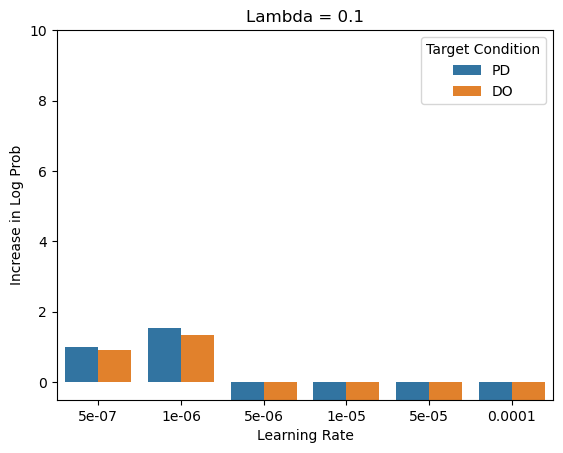

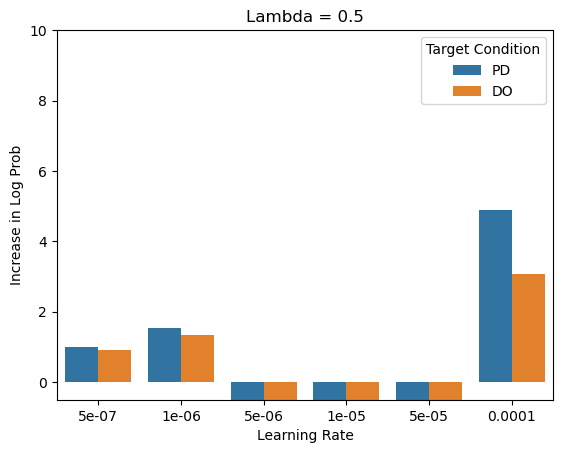

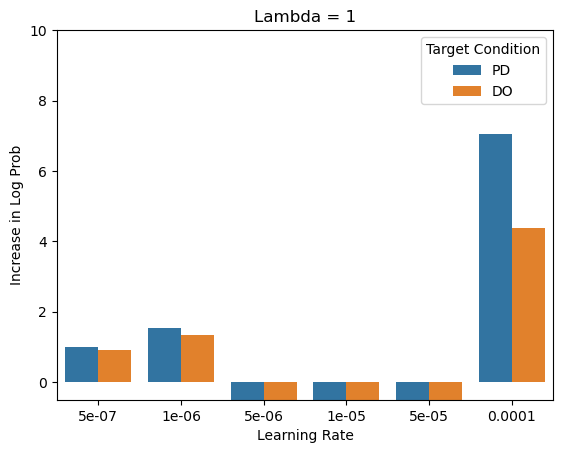

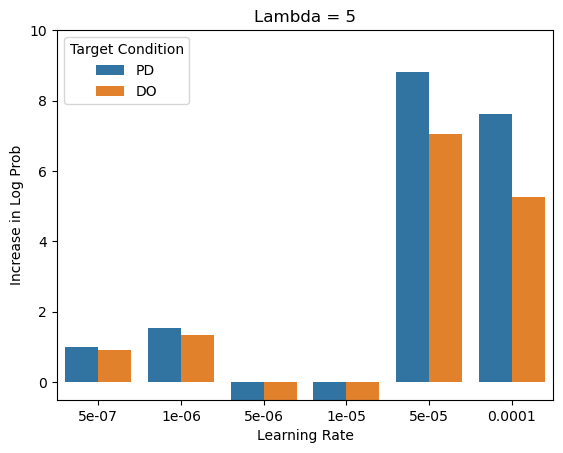

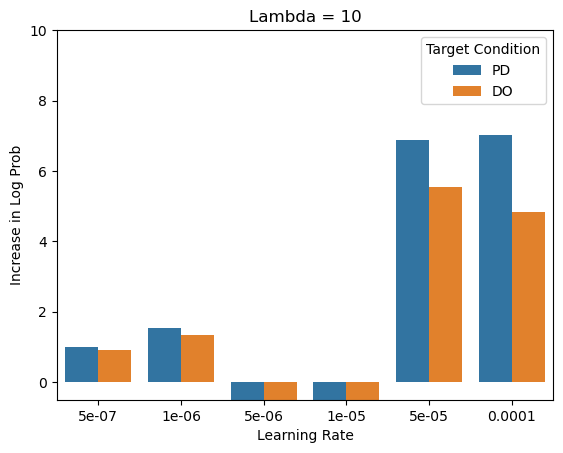

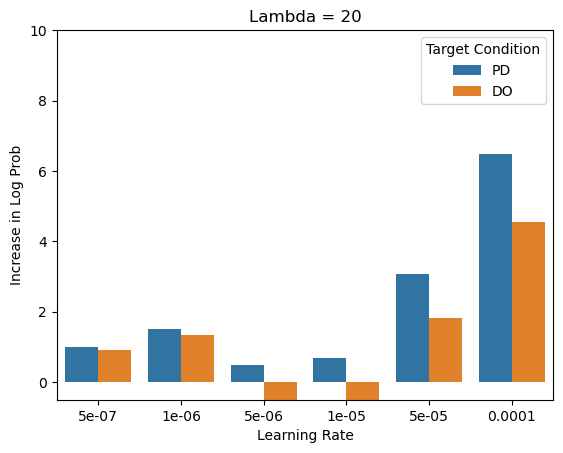

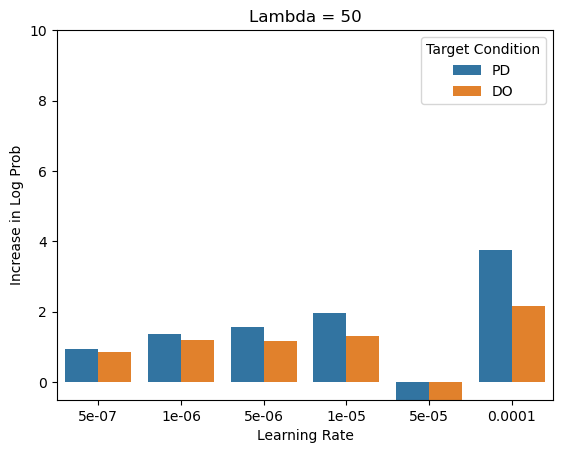

##################### Prime = DO #####################


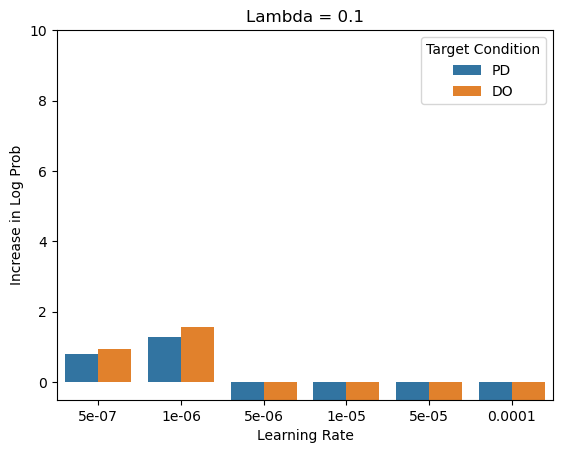

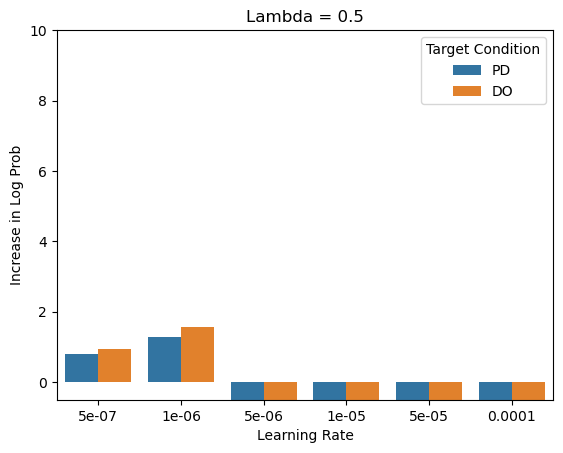

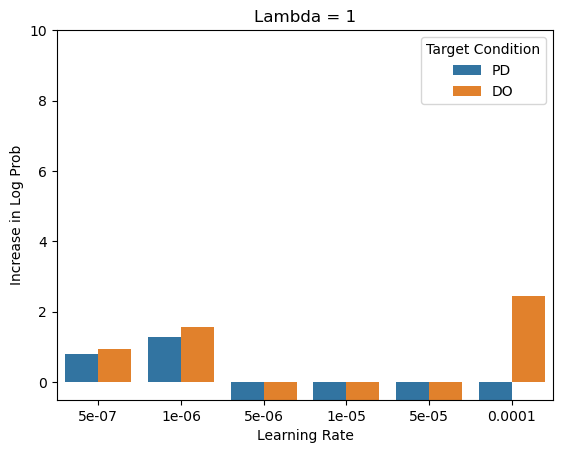

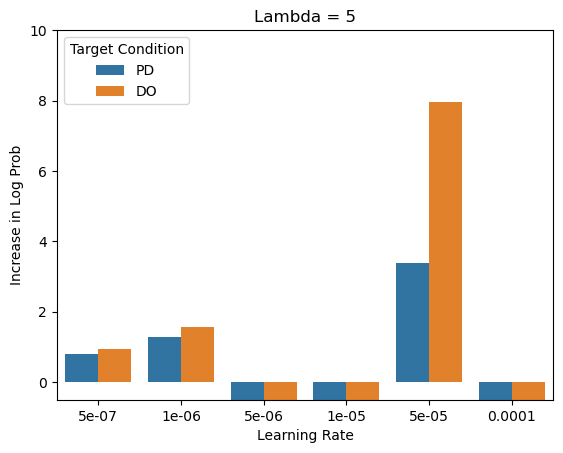

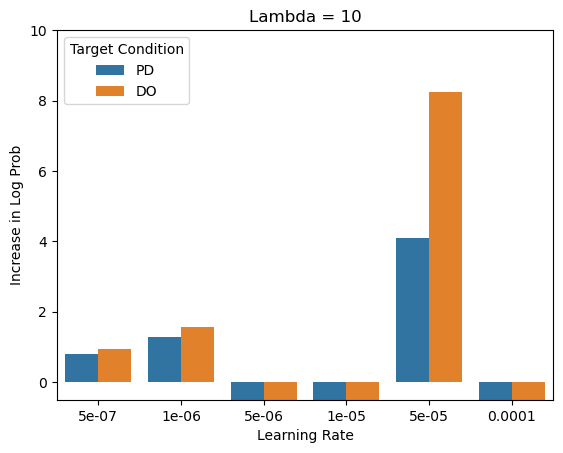

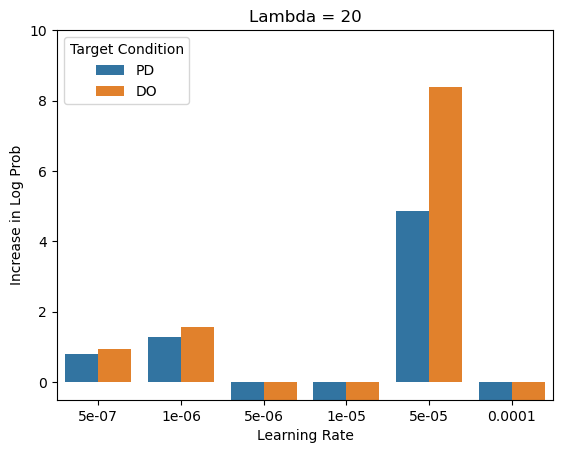

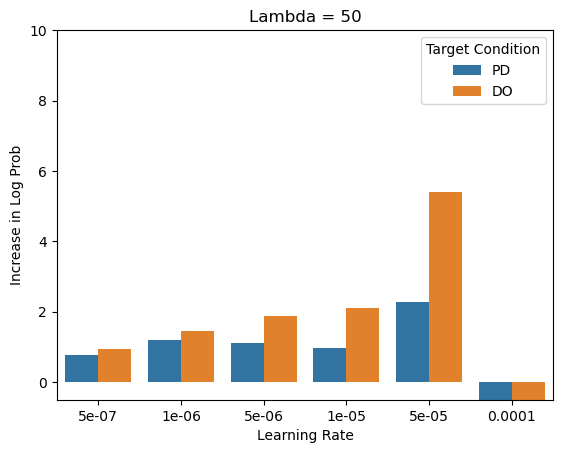

In [36]:
df = pd.read_csv(f'{root_dir}fine-tuning/Hyperparameter/Hypersearch_{SIZE}_{FILLER_SIZE}_{file_Padding}.csv')
df.loc[df['PD']<0, 'PD'] = -0.5
df.loc[df['DO']<0, 'DO'] = -0.5

for structure in ['PD', 'DO']:
    print(f'##################### Prime = {structure} #####################')
    for LAMB in [0.1, 0.5, 1, 5, 10, 20, 50]: 
        df_sub = df[(df['lambda'] == LAMB) & (df['prime_structure'] == structure)][['lr','PD','DO']]
        df_melted = df_sub.melt(id_vars = 'lr', var_name='Target Condition', value_name='Priming Dev')
        sns.barplot(data=df_melted, x='lr', y='Priming Dev', hue='Target Condition')
        plt.ylim(-0.5, 10)
        plt.xlabel('Learning Rate')
        plt.ylabel('Increase in Log Prob')
        plt.title(f'Lambda = {LAMB}')
        plt.show()

# Exp Results

### No Padding, Full Batch

In [18]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD, sen_prob_DO

Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
26436.698112
33384.562688
33384.562688
33384.562688
33384.562688
33384.562688
33384.562688
33384.562688
33384.562688
33384.562688


(-49.660125732421875, -49.671287536621094)

In [19]:
sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

(-1.829742431640625, -3.674121856689453)

### No Padding, Sen by Sen

In [12]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
18324.914176
25323.1104
25323.1104
25323.1104
25323.1104
25321.013248
25323.1104
25321.013248
25321.013248
25321.013248


(-1.9769554138183594, -3.708179473876953)

### No Padding, Sen by Sen DIVIDED by #sentences

In [ ]:
# raw_model = HookedTransformer.from_pretrained(model_name, device=device)
# torch.cuda.empty_cache()
# gc.collect()

# train_config = HookedTransformerTrainConfig(
#     num_epochs=10,
#     batch_size=1,
#     lr=LR,
#     lamb = LAMB,
#     optimizer_name="AdamW")

# data = ['The professor made the key for the president.']
# dataset = FineTuningDataset(data)
# adapted_model = train(raw_model, train_config, dataset, raw_loss)
# output_PD = adapted_model(targetPD)
# output_DO = adapted_model(targetDO)

# sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
# sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

# sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

### With Padding, Big

In [10]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
22041.06752
28995.223552
28991.029248
28993.1264
28991.029248
28991.029248
28991.029248
28991.029248
28991.029248
28991.029248


(8.09847640991211, 4.394248962402344)

### No Padding, Big, Step by Step

In [10]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
21057.503232
28026.339328
28026.339328
28026.339328
28026.339328
28026.339328
28026.339328
28026.339328
28026.339328
28026.339328


(-0.21018218994140625, 1.2012596130371094)

## GPT2-SMALL

### Small, Mid, Sen-by-sen, Original Fillers

In [10]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

Loaded pretrained model gpt2-small into HookedTransformer
Moving model to device:  cuda
4060.086272
5402.263552
5402.263552
5406.457856
5402.263552
5402.263552
5402.263552
5402.263552
5402.263552
5402.263552


(2.398517608642578, 2.457408905029297)

### Small, Mid, Full-batch, Original Fillers

In [13]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

Loaded pretrained model gpt2-small into HookedTransformer
Moving model to device:  cuda
22741.516288
24062.722048
24062.722048
24062.722048
24062.722048
24062.722048
24062.722048
24062.722048
24062.722048
24062.722048


(2.2916908264160156, 2.266979217529297)

### Small, Mid, Sen-by-sen, Shifted Fillers

In [45]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

Loaded pretrained model gpt2-small into HookedTransformer
Moving model to device:  cuda
11286.872064
12654.215168
12654.215168
12654.215168
12654.215168
12654.215168
12654.215168
12654.215168
12654.215168
12654.215168


(2.2588768005371094, 2.3015098571777344)

### Small, Mid, Full-batch, Shifted Fillers

In [33]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

Loaded pretrained model gpt2-small into HookedTransformer
Moving model to device:  cuda
17297.309696
18658.361344
18658.361344
18658.361344
18658.361344
18658.361344
18658.361344
18658.361344
18658.361344
18658.361344


(2.2201156616210938, 2.254100799560547)

## Large

### Big, Sen-by-Sen (cannot do Full batch), Original Fillers

In [10]:
LR = 5e-5
LAMB = 1

raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
22041.06752
28995.223552
28991.029248
28993.1264
28991.029248
28991.029248
28991.029248
28991.029248
28991.029248
28991.029248


(8.09847640991211, 4.394248962402344)

### Big, Sen-by-Sen (cannot do full batch), Shifted Fillers

In [20]:
LR = 5e-5
LAMB = 1

raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
24582.815744
31572.62336
31572.62336
31572.62336
31572.62336
31572.62336
31572.62336
31572.62336
31572.62336
31572.62336


(-0.21018218994140625, 1.2012596130371094)

### This is amazing: test on other prime-target

- Professor Prime, Princess Target: 3.3, 1.6
- Secretary Prime, Princess Target: 1.7, -0.24
- Professor Prime, Soldier Target: 8.1, 4.4
- Secretary Prime, Soldier Target: 4.75, 1.13

With XL filler:
- Professor Prime, Princess Target: 2.61, 0.57 (wrong PD Form: 1.66, 0.57)
- Secretary Prime, Princess Target: 3.5, 3.3(wrong PD Form: 4.1, 3.3)
- Professor Prime, Soldier Target: 9.5, 6.3
- Secretary Prime, Soldier Target: 7.3, 6.2

In [15]:
LR = 5e-5
LAMB = 1

raw_model = HookedTransformer.from_pretrained(model_name, device=device)

targetPD = 'A princess brought a coffee to an adult.'
targetDO = 'A princess brought an adult a coffee.'

output_PD = raw_model(targetPD)
output_DO = raw_model(targetDO)


baseline_PD,_ = get_log_prob(targetPD, output_PD)
baseline_DO,_ = get_log_prob(targetDO, output_DO)

print(f'######{baseline_PD}, {baseline_DO}#####')

raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

#data = ['The professor made the key for the president.']
data = ['The secretary drew the card for the band.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD-baseline_PD, sen_prob_DO-baseline_DO

Loaded pretrained model gpt2-large into HookedTransformer
######-49.657989501953125, -49.31305694580078#####
Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
29712.449536
36647.7312
36647.7312
36647.7312
36647.7312
36647.7312
36647.7312
36647.7312
36647.7312
36647.7312


(3.505786895751953, 3.289379119873047)